In [8]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import models, layers
from keras import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,BatchNormalization,Dropout, GlobalAveragePooling2D
from tensorflow.keras.regularizers import l2

In [9]:
# generators
dataset_path = "C:\\Users\\Gamer Tech\\Desktop\\potato"  

train_ds = keras.utils.image_dataset_from_directory(
    directory = "C:\\Users\\Gamer Tech\\Desktop\\potato\\Training",
    labels='inferred',
    label_mode = 'int',
    batch_size=32,
    image_size=(256,256)
)

validation_ds = keras.utils.image_dataset_from_directory(
    directory = "C:\\Users\\Gamer Tech\\Desktop\\potato\\Validation",
    labels='inferred',
    label_mode = 'int',
    batch_size=32,
    image_size=(256,256)
)

Found 3111 files belonging to 3 classes.
Found 556 files belonging to 3 classes.


In [12]:
# Normalize
def process(image,label):
    image = tf.cast(image/255. ,tf.float32)
    return image,label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

In [14]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip(mode="horizontal_and_vertical"),
    layers.RandomRotation(factor = 0.5)
])

In [16]:
# creating CNN model

model = Sequential()

model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(256, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(512, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

model.add(GlobalAveragePooling2D())

model.add(Dense(128, activation='relu', kernel_regularizer=l2(0.001)))
model.add(Dropout(0.4))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(3,activation='softmax'))

D:\newfolder\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,646,659 (6.28 MB)

 Trainable params: 1,644,675 (6.27 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [20]:
import os

train_dir = "C:\\Users\\Gamer Tech\\Desktop\\potato\\Training"
class_names = sorted(os.listdir(train_dir))  # Get folder names as class labels
print("Class Names:", class_names)  # Check extracted class names


Class Names: ['Early_Blight', 'Healthy', 'Late_Blight']


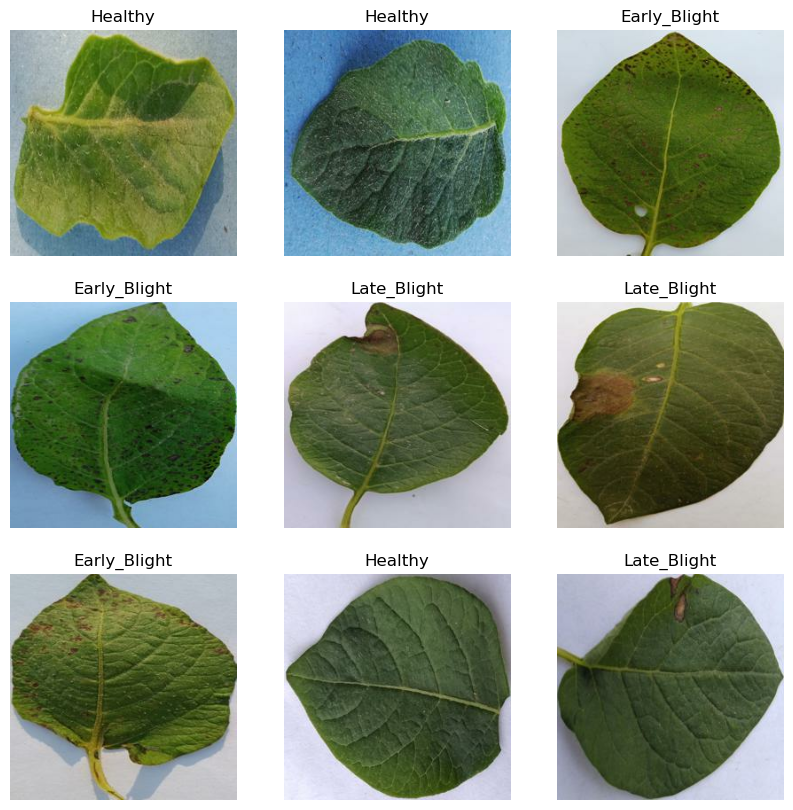

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow((images[i].numpy() * 255).astype("uint8"))
        plt.title(class_names[labels[i].numpy()])
        plt.axis("off")
plt.show()


tf.Tensor([1 0 0 0 1], shape=(5,), dtype=int32)


In [24]:
from tensorflow.keras.optimizers import Adam

model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [28]:
history = model.fit(train_ds,epochs=20,validation_data=validation_ds)

Epoch 1/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 187s 2s/step - accuracy: 0.6580 - loss: 1.0140 - val_accuracy: 0.1835 - val_loss: 2.6556
Epoch 2/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 182s 2s/step - accuracy: 0.7443 - loss: 0.8266 - val_accuracy: 0.1835 - val_loss: 4.1475
Epoch 3/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 195s 2s/step - accuracy: 0.8000 - loss: 0.7251 - val_accuracy: 0.1835 - val_loss: 4.8955
Epoch 4/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 195s 2s/step - accuracy: 0.8476 - loss: 0.6189 - val_accuracy: 0.2302 - val_loss: 3.1596
Epoch 5/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 196s 2s/step - accuracy: 0.8519 - loss: 0.5823 - val_accuracy: 0.4676 - val_loss: 2.5995
Epoch 6/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 198s 2s/step - accuracy: 0.8871 - loss: 0.4995 - val_accuracy: 0.6924 - val_loss: 1.6565
Epoch 7/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 199s 2s/step - accuracy: 0.9036 - loss: 0.4676 - val_accuracy: 0.7752 - val_loss: 1.3850
Epoch 8/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 200s 2s/step - accuracy: 0.9288 - loss: 0.4330 - val_accuracy: 0.8273 - v

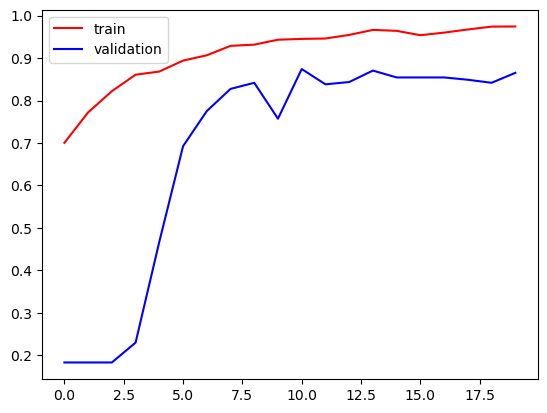

In [64]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

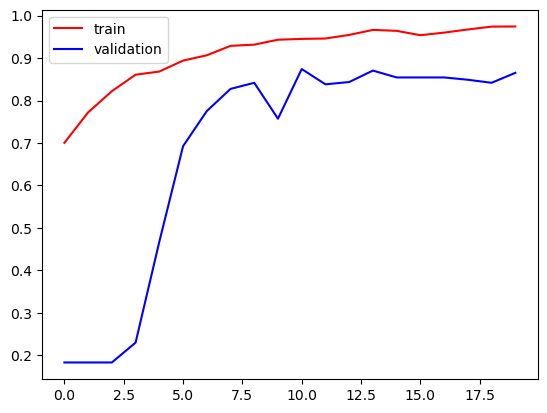

In [66]:
plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

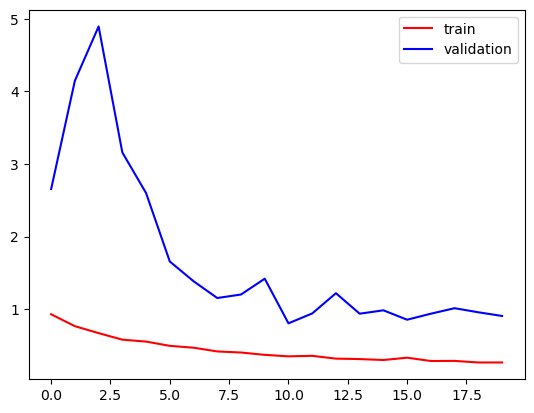

In [68]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

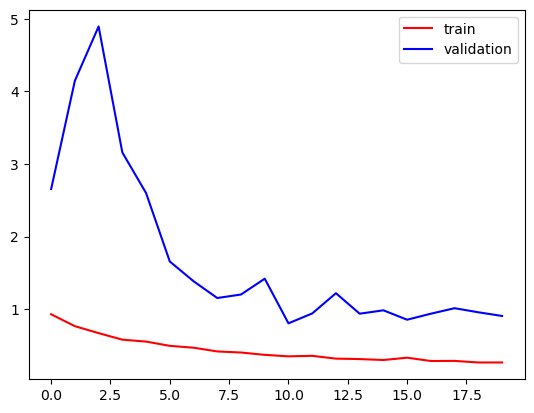

In [482]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

In [452]:
from PIL import Image

image_path = r"C:\Users\Gamer Tech\Desktop\potato\Testing\Early_Blight\Early_Blight_15.jpg"


img = Image.open(image_path)
img.show()  # Opens the image in default viewer
print("Image loaded successfully with PIL!")



Image loaded successfully with PIL!


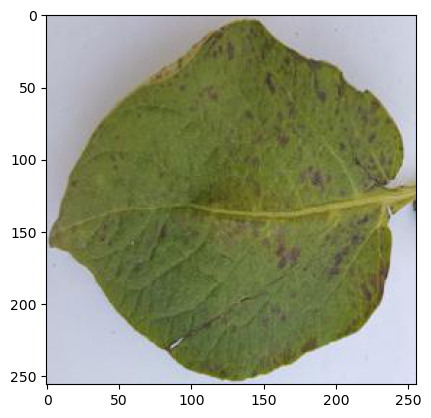

In [454]:
plt.imshow(img)

In [456]:
import numpy as np

img_array = np.array(img)
img_array = img_array / 255.0  

img_array.shape

(256, 256, 3)

In [458]:
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


In [460]:
print("Raw Model Output:", prediction)


Raw Model Output: [[9.9997330e-01 7.9371131e-07 2.5886213e-05]]


In [462]:
class_labels = dataset.class_names  # Dynamically get correct labels
predicted_index = np.argmax(prediction)  # Get index of highest probability
predicted_label = class_labels[predicted_index]  # Match with class

print(f"Corrected Predicted Class: {predicted_label}")

Corrected Predicted Class: Early_Blight


In [464]:
print("Processed Image Shape:", img_array.shape)  # Should be (1, 256, 256, 3)


Processed Image Shape: (1, 256, 256, 3)


In [486]:
for i, label in enumerate(class_labels):
    print(f"{label}: {prediction[0][i]*100:.2f}%")


Early_Blight: 100.00%
Healthy: 0.00%
Late_Blight: 0.00%


In [488]:
import tensorflow as tf

dataset = tf.keras.utils.image_dataset_from_directory("C:\\Users\\Gamer Tech\\Desktop\\potato\\Testing")
class_names = dataset.class_names  # Get actual class names in order

print(class_names)  # This shows the actual order used in training


Found 405 files belonging to 3 classes.
['Early_Blight', 'Healthy', 'Late_Blight']


In [504]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator


test_datagen = ImageDataGenerator(rescale=1./255)

#  test dataset 
test_generator = test_datagen.flow_from_directory(
    r"C:\Users\Gamer Tech\Desktop\potato\Testing", 
    target_size=(256, 256),
    batch_size=32,
    class_mode="sparse",
    shuffle=False
)


Found 405 images belonging to 3 classes.


In [506]:
# Evaluate model on test data
loss, accuracy = model.evaluate(test_generator, verbose=1)

# Print Accuracy
print(f"Model Accuracy: {accuracy * 100:.2f}%")


13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 489ms/step - accuracy: 0.9671 - loss: 0.2744
Model Accuracy: 96.05%


In [478]:
model.save("C:/Users/Gamer Tech/Desktop/FYP/Models/potato_disease_model.h5") 

